In [29]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt

In [30]:
df = pd.read_csv("Data.csv")
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [31]:
df.shape


(7043, 21)

In [32]:
df.info()
df['Churn'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [33]:
# Description about dataset
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [34]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [35]:
# null values

df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [36]:
#convert this column to numeric, might be some missing values present
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [37]:
# All Nans of TotalCharges has zero tenure. That's why we can assume TotalCharges = MonthlyCharges. They're fresh customers.
df[df['TotalCharges'].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [38]:
# Change Total Charges values with Monthly Charges where is nan.
df.loc[df['TotalCharges'].isnull(), 'TotalCharges'] = df.loc[df['TotalCharges'].isnull(), 'MonthlyCharges']
     

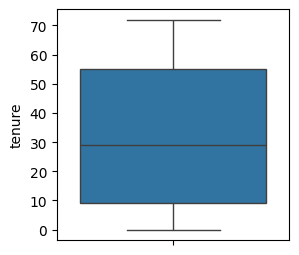

In [43]:
# Check for outliers.
plt.figure(figsize=(3,3))
sns.boxplot(df.tenure)
plt.show()
     

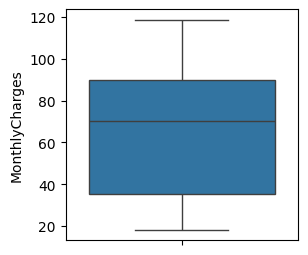

In [45]:
# Check for outliers.
plt.figure(figsize=(3,3))
sns.boxplot(df.MonthlyCharges)
plt.show()

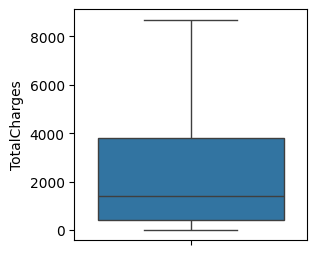

In [46]:
# Check for outliers.
plt.figure(figsize=(3,3))
sns.boxplot(df["TotalCharges"])
plt.show()
     

In [47]:
# Let's look all values in every column.
for i in df.columns:
  print(f"Column '{i}' has : {df[i].unique()}")

Column 'customerID' has : ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
Column 'gender' has : ['Female' 'Male']
Column 'SeniorCitizen' has : [0 1]
Column 'Partner' has : ['Yes' 'No']
Column 'Dependents' has : ['No' 'Yes']
Column 'tenure' has : [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
Column 'PhoneService' has : ['No' 'Yes']
Column 'MultipleLines' has : ['No phone service' 'No' 'Yes']
Column 'InternetService' has : ['DSL' 'Fiber optic' 'No']
Column 'OnlineSecurity' has : ['No' 'Yes' 'No internet service']
Column 'OnlineBackup' has : ['Yes' 'No' 'No internet service']
Column 'DeviceProtection' has : ['No' 'Yes' 'No internet service']
Column 'TechSupport' has : ['No' 'Yes' 'No internet service']
Column 'StreamingTV' has : ['No' 'Yes' 'No internet service']
Column 'Stream

In [49]:
# Get dummies for every value in categoric features.
# Get dummies for just positive values in binary features.
numerical_features = ["tenure", "MonthlyCharges", "TotalCharges"]
categoric_features = ["MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies", "Contract", "PaymentMethod"]
binary_features = ["gender", "SeniorCitizen", "Partner", "Dependents", "PhoneService", "PaperlessBilling", "Churn"]
data_encoded = pd.get_dummies(df, columns=categoric_features)
data_encoded = pd.get_dummies(data_encoded, columns=binary_features, drop_first=True)
     

In [50]:

print(f"Data Columns: {len(df.columns)}\nEncoded Data Columns: {len(data_encoded.columns)}")
     

Data Columns: 21
Encoded Data Columns: 42


In [51]:
# All Clean
data_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 42 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   customerID                               7043 non-null   object 
 1   tenure                                   7043 non-null   int64  
 2   MonthlyCharges                           7043 non-null   float64
 3   TotalCharges                             7043 non-null   float64
 4   MultipleLines_No                         7043 non-null   bool   
 5   MultipleLines_No phone service           7043 non-null   bool   
 6   MultipleLines_Yes                        7043 non-null   bool   
 7   InternetService_DSL                      7043 non-null   bool   
 8   InternetService_Fiber optic              7043 non-null   bool   
 9   InternetService_No                       7043 non-null   bool   
 10  OnlineSecurity_No                        7043 no

## Feature Engineering

In [52]:
# Later use to compare the benefits of feature engineering
data_test = data_encoded.copy()

In [53]:
# Investigate tenure, MonthlyCharges and TotalCharges
# Create a new feature for average charges but when tenure is 0 we need to assign TotalCharges
data_encoded["AverageCharges"] =  data_encoded["TotalCharges"] / data_encoded["tenure"]
data_encoded.loc[data_encoded["tenure"] == 0, "AverageCharges"] = data_encoded["TotalCharges"]
     

In [54]:
# Create a new feature when monthly charges are above average charges
data_encoded["AboveAverageCharges"] = (data_encoded["MonthlyCharges"] > data_encoded["AverageCharges"].mean()).astype(int)
     

In [55]:
# This information can be useful
data_encoded["AboveAverageCharges"].value_counts()

AboveAverageCharges
1    3923
0    3120
Name: count, dtype: int64

In [62]:
#converting the boolean type features to the numerical type
cols_to_convert = ['MultipleLines_No', 'MultipleLines_No phone service', 'MultipleLines_Yes',
                  'InternetService_DSL','InternetService_Fiber optic','InternetService_No','OnlineSecurity_No',
                   'OnlineSecurity_No internet service','OnlineSecurity_Yes','OnlineBackup_No','OnlineBackup_No internet service',
                   'TechSupport_No','TechSupport_No internet service','TechSupport_Yes', 'StreamingTV_No',
                   'StreamingTV_No internet service','StreamingTV_Yes','StreamingMovies_No','StreamingMovies_No internet service',
                   'StreamingMovies_Yes','Contract_Month-to-month','Contract_One year','Contract_Two year','PaymentMethod_Bank transfer (automatic)',
                    'PaymentMethod_Credit card (automatic)','PaymentMethod_Electronic check','PaymentMethod_Mailed check','gender_Male','SeniorCitizen_1','Partner_Yes',
                   'Dependents_Yes','PhoneService_Yes','PaperlessBilling_Yes','Churn_Yes' ]

data_encoded[cols_to_convert] = data_encoded[cols_to_convert].astype(int)

In [68]:
# Let's get rid of them and just keep InternetService_No
columns_to_delete = [
                    'OnlineSecurity_No internet service',
                    'OnlineBackup_No internet service',
                    'DeviceProtection_No internet service',
                    'TechSupport_No internet service',
                    'StreamingTV_No internet service',
                    'StreamingMovies_No internet service']
data_encoded.drop(columns=columns_to_delete, inplace=True)
print(f"Number of Columns: {len(data_encoded.columns)}")

Number of Columns: 38


In [77]:
data_encoded.drop(columns = ['customerID'],inplace = True)

In [78]:
# Add a column to identify persons who use services most
services = [
    'MultipleLines_Yes',
    'InternetService_DSL',
    'InternetService_Fiber optic',
    'OnlineSecurity_Yes',
    'OnlineBackup_Yes',
    'DeviceProtection_Yes',
    'TechSupport_Yes',
    'StreamingTV_Yes',
    'StreamingMovies_Yes',
    'PhoneService_Yes',
    'PaperlessBilling_Yes']

# Create a new column to identify persons who use services the most
data_encoded['ServicesMost'] = data_encoded[services].mean(axis=1)

In [79]:
data_encoded.ServicesMost.value_counts(ascending=True)

ServicesMost
0.909091    130
0.818182    356
0.727273    597
0.272727    722
0.181818    787
0.636364    813
0.090909    894
0.363636    898
0.454545    900
0.545455    946
Name: count, dtype: int64

In [80]:
# There is no need for No columns anymore.
data_encoded.columns

Index(['tenure', 'MonthlyCharges', 'TotalCharges', 'MultipleLines_No',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_DSL', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_No', 'OnlineSecurity_Yes',
       'OnlineBackup_No', 'OnlineBackup_Yes', 'DeviceProtection_No',
       'DeviceProtection_Yes', 'TechSupport_No', 'TechSupport_Yes',
       'StreamingTV_No', 'StreamingTV_Yes', 'StreamingMovies_No',
       'StreamingMovies_Yes', 'Contract_Month-to-month', 'Contract_One year',
       'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'gender_Male', 'SeniorCitizen_1', 'Partner_Yes', 'Dependents_Yes',
       'PhoneService_Yes', 'PaperlessBilling_Yes', 'Churn_Yes',
       'AverageCharges', 'AboveAverageCharges', 'ServicesMost'],
      dtype='object')

In [81]:
columns_to_keep = ['tenure', 'MonthlyCharges', 'TotalCharges', 'MultipleLines_Yes',
                     'InternetService_DSL', 'InternetService_Fiber optic', 'OnlineSecurity_Yes',
                     'OnlineBackup_Yes', 'DeviceProtection_Yes', 'TechSupport_Yes', 'StreamingTV_Yes',
                     'StreamingMovies_Yes', 'Contract_Month-to-month', 'Contract_One year',
                     'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)',
                     'PaymentMethod_Credit card (automatic)', 'InternetService_No',
                     'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
                     'gender_Male', 'SeniorCitizen_1', 'Partner_Yes', 'Dependents_Yes',
                     'PhoneService_Yes', 'PaperlessBilling_Yes', 'Churn_Yes',
                     'AverageCharges', 'AboveAverageCharges', 'ServicesMost']

data_encoded = data_encoded[columns_to_keep]

In [82]:
print(f"Total Columns Left: {data_encoded.shape[1]}")

Total Columns Left: 30


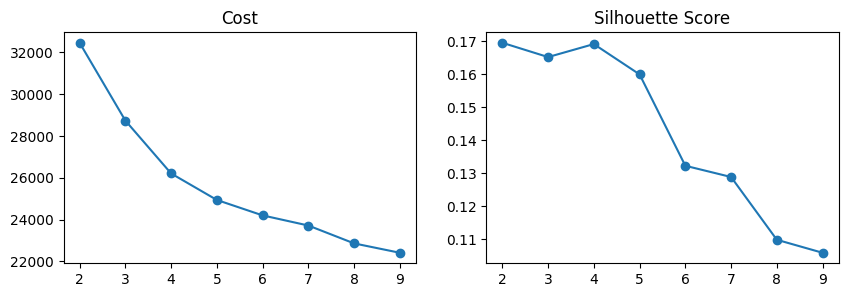

In [83]:
# We'll use Kmeans to assign clusters as new feauture
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MinMaxScaler
     

# Scale data using MinMaxScaler because it's mostly binary data
scaler = MinMaxScaler()
scaled_data = data_encoded.drop("Churn_Yes", axis=1)
scaled_data = scaler.fit_transform(data_encoded)
     

# Calculate and plot costs and silhouette scores for KMeans
costs = []
silhouette_scores = []

for i in range(2, 10):
    kmeans = KMeans(n_clusters=i, random_state=0, n_init="auto").fit(scaled_data)
    costs.append(kmeans.inertia_)

    silhouette_avg = silhouette_score(scaled_data, kmeans.labels_)
    silhouette_scores.append(silhouette_avg)

plt.figure(figsize=(10, 3))

plt.subplot(1, 2, 1)
plt.plot(range(2, 10), costs, marker='o')
plt.title('Cost')

plt.subplot(1, 2, 2)
plt.plot(range(2, 10), silhouette_scores, marker='o')
plt.title('Silhouette Score')
plt.show()

In [84]:
# According to results my intuition is picking K-Means with n = 5
# It's a maximum number we can assign as cluster number for adding a new feature to improve model's performance
km = KMeans(n_clusters=5, n_init=5, verbose=0, random_state=0)
km.fit_predict(scaled_data)
data_encoded["cluster"] = km.labels_

C:\Users\mehak\AppData\Local\Temp\ipykernel_9868\904159628.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_encoded["cluster"] = km.labels_


## Data Analysis

In [85]:
data_encoded.describe()

,tenure,MonthlyCharges,TotalCharges,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,OnlineSecurity_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,...,gender_Male,SeniorCitizen_1,Partner_Yes,Dependents_Yes,PhoneService_Yes,PaperlessBilling_Yes,Churn_Yes,AverageCharges,AboveAverageCharges,cluster
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,...,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.798992,0.421837,0.343746,0.439585,0.286668,0.290217,0.384353,0.387903,...,0.504756,0.162147,0.483033,0.299588,0.903166,0.592219,0.265370,64.762906,0.557007,1.802215
std,24.559481,30.090047,2266.730170,0.493888,0.474991,0.496372,0.452237,0.453895,0.486477,0.487307,...,0.500013,0.368612,0.499748,0.458110,0.295752,0.491457,0.441561,30.189796,0.496775,1.395182
min,0.000000,18.250000,18.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,13.775000,0.000000,0.000000
25%,9.000000,35.500000,398.550000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,35.935156,0.000000,1.000000
50%,29.000000,70.350000,1394.550000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,70.337500,1.000000,2.000000
75%,55.000000,89.850000,3786.600000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,90.174158,1.000000,3.000000
max,72.000000,118.750000,8684.800000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,121.400000,1.000000,4.000000


In [86]:
# Divide data to different categories for better understanding
numerical = ['tenure', 'MonthlyCharges', 'TotalCharges',
             'AverageCharges', 'AboveAverageCharges', 'ServicesMost', 'Churn_Yes']

services = ['MultipleLines_Yes', 'InternetService_DSL', 'InternetService_Fiber optic', 'OnlineSecurity_Yes',
            'OnlineBackup_Yes', 'DeviceProtection_Yes','TechSupport_Yes', 'StreamingTV_Yes',
            'StreamingMovies_Yes', 'InternetService_No', 'PhoneService_Yes', 'PaperlessBilling_Yes', 'ServicesMost', 'Churn_Yes']

demographic = ['gender_Male', 'SeniorCitizen_1', 'Partner_Yes', 'Dependents_Yes', 'Churn_Yes', 'cluster']

other = ['Contract_Month-to-month', 'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'Churn_Yes']
     

In [87]:
# Check average correlation for all
correlation_matrix_all = data_encoded.corr()
abs(correlation_matrix_all).mean()

tenure                                     0.284518
MonthlyCharges                             0.396263
TotalCharges                               0.379814
MultipleLines_Yes                          0.233966
InternetService_DSL                        0.180577
InternetService_Fiber optic                0.306371
OnlineSecurity_Yes                         0.223701
OnlineBackup_Yes                           0.246032
DeviceProtection_Yes                       0.264236
TechSupport_Yes                            0.242017
StreamingTV_Yes                            0.275870
StreamingMovies_Yes                        0.278574
Contract_Month-to-month                    0.242107
Contract_One year                          0.125178
Contract_Two year                          0.201308
PaymentMethod_Bank transfer (automatic)    0.128854
PaymentMethod_Credit card (automatic)      0.131508
InternetService_No                         0.333845
PaymentMethod_Electronic check             0.203549
PaymentMetho

In [88]:
# Check average correlation for numerical
correlation_matrix_num = data_encoded[numerical].corr()
abs(correlation_matrix_num).mean()

tenure                 0.469757
MonthlyCharges         0.690098
TotalCharges           0.656670
AverageCharges         0.688903
AboveAverageCharges    0.617897
ServicesMost           0.661954
Churn_Yes              0.308525
dtype: float64

In [89]:
# Check average correlation for services
correlation_matrix_serv = data_encoded[services].corr()
abs(correlation_matrix_serv).mean()

MultipleLines_Yes              0.278087
InternetService_DSL            0.284384
InternetService_Fiber optic    0.348374
OnlineSecurity_Yes             0.272758
OnlineBackup_Yes               0.299631
DeviceProtection_Yes           0.320249
TechSupport_Yes                0.297091
StreamingTV_Yes                0.333137
StreamingMovies_Yes            0.334606
InternetService_No             0.409181
PhoneService_Yes               0.190831
PaperlessBilling_Yes           0.229496
ServicesMost                   0.493448
Churn_Yes                      0.180920
dtype: float64

In [90]:
# Check average correlation for demographic
correlation_matrix_demo = data_encoded[demographic].corr()
abs(correlation_matrix_demo).mean()

gender_Male        0.170600
SeniorCitizen_1    0.239315
Partner_Yes        0.287033
Dependents_Yes     0.309754
Churn_Yes          0.255428
cluster            0.205894
dtype: float64

In [91]:
# Check average correlation for other
correlation_matrix_other = data_encoded[other].corr()
abs(correlation_matrix_other).mean()

Contract_Month-to-month                    0.414516
Contract_One year                          0.283795
Contract_Two year                          0.353622
PaymentMethod_Bank transfer (automatic)    0.306653
PaymentMethod_Credit card (automatic)      0.314611
PaymentMethod_Electronic check             0.395288
PaymentMethod_Mailed check                 0.257844
Churn_Yes                                  0.316377
dtype: float64

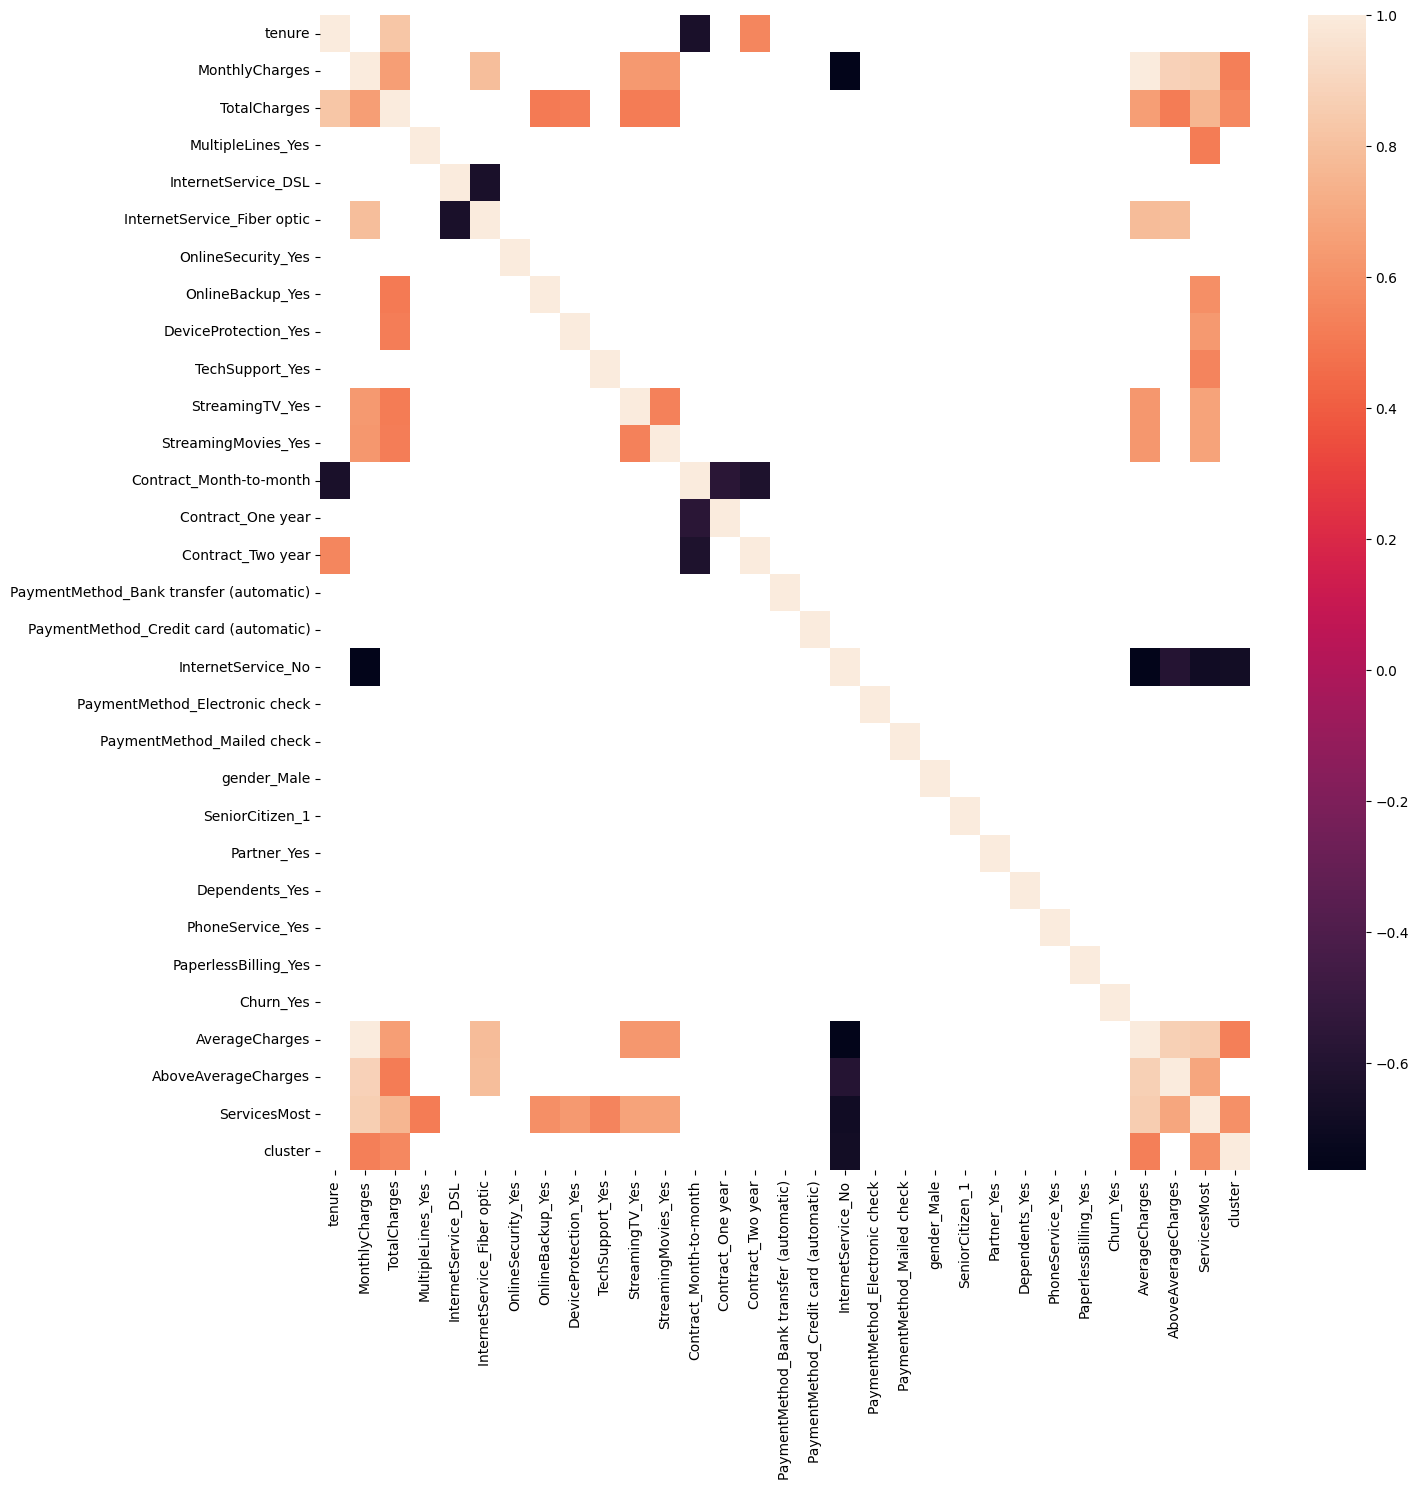

In [92]:
# Create a correlation matrix heatmap for all
mask = (np.abs(correlation_matrix_all) < 0.5)
plt.figure(figsize=(15, 15))
sns.heatmap(correlation_matrix_all, mask=mask)
plt.show()

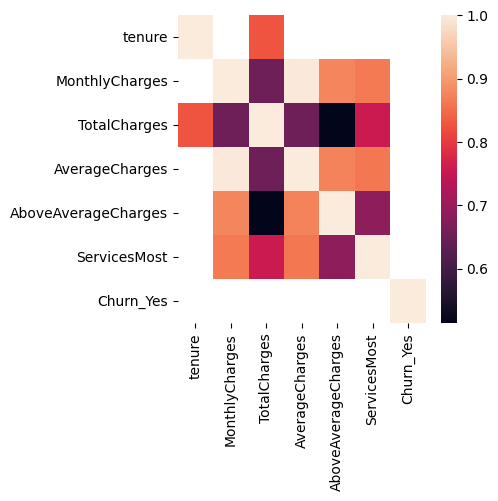

In [93]:
# Create a correlation matrix heatmap for numerical
mask = (np.abs(correlation_matrix_num) < 0.5)
plt.figure(figsize=(4, 4))
sns.heatmap(correlation_matrix_num, mask=mask)
plt.show()

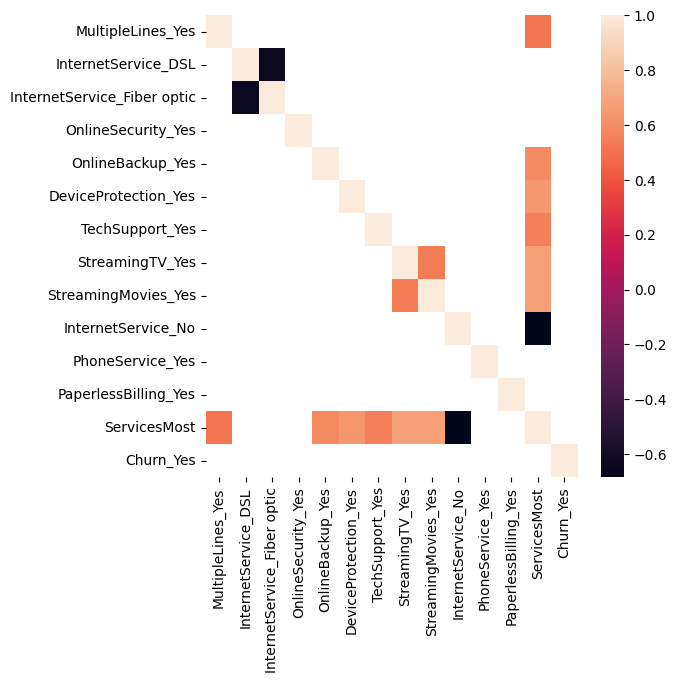

In [94]:
#Create a correlation matrix heatmap for services
mask = (np.abs(correlation_matrix_serv) < 0.5)
plt.figure(figsize=(6, 6))
sns.heatmap(correlation_matrix_serv, mask=mask)
plt.show()

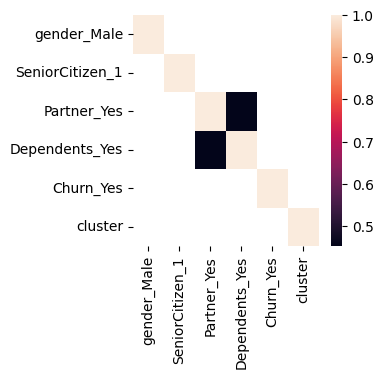

In [95]:
# Create a correlation matrix heatmap for demographic
mask = (np.abs(correlation_matrix_demo) < 0.3)
plt.figure(figsize=(3, 3))
sns.heatmap(correlation_matrix_demo, mask=mask)
plt.show()

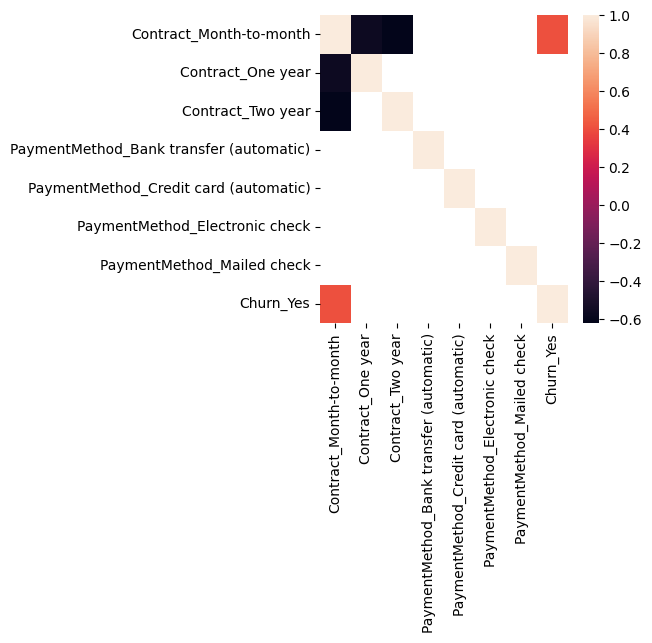

In [96]:
# Create a correlation matrix heatmap for other
mask = (np.abs(correlation_matrix_other) < 0.4)
plt.figure(figsize=(4, 4))
sns.heatmap(correlation_matrix_other, mask=mask)
plt.show()

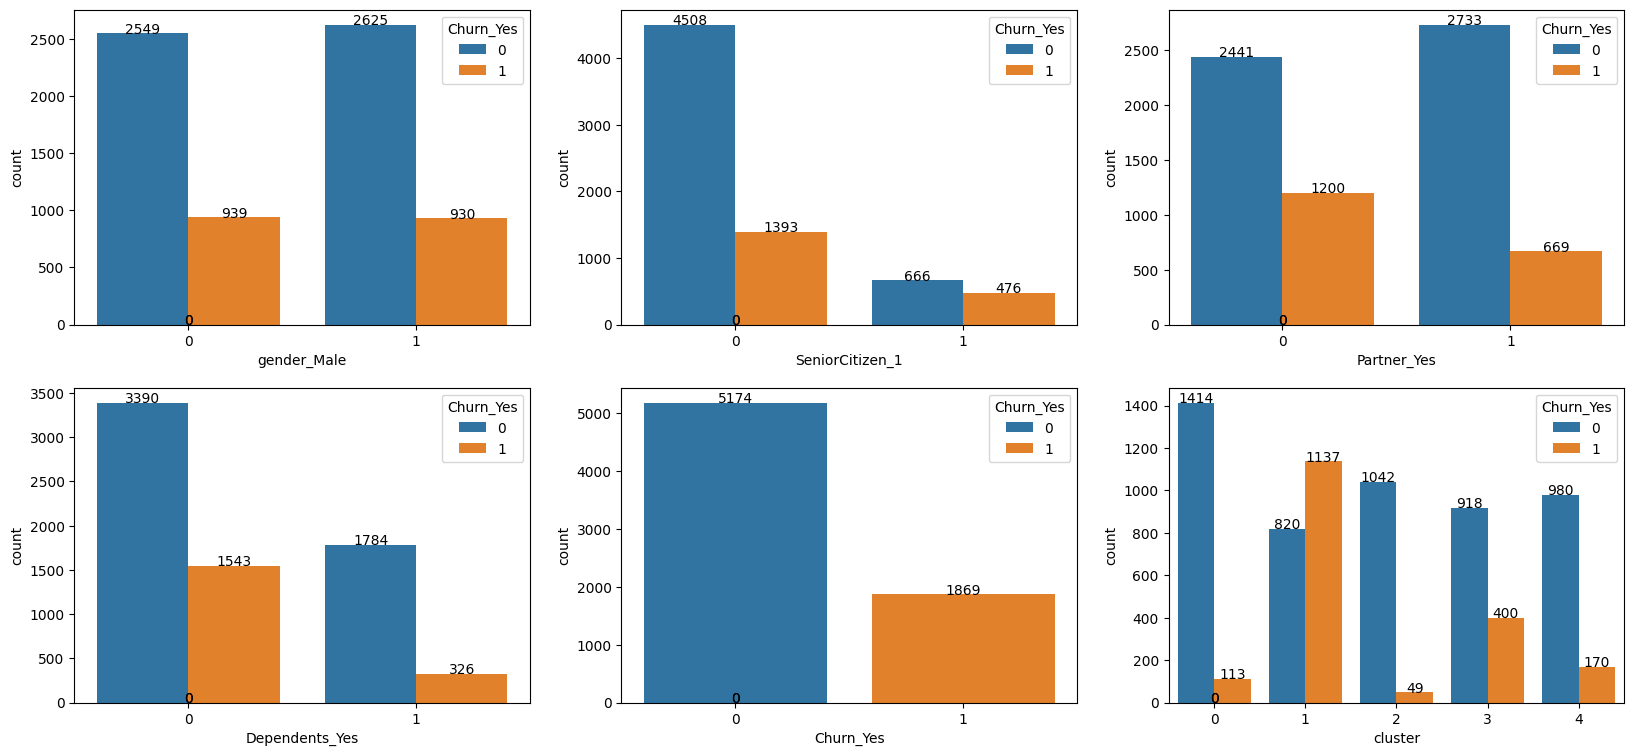

In [97]:
# Create countplot for every demographic features
plt.figure(figsize=(20,9))
for i, column in enumerate(data_encoded[demographic]):
    plt.subplot(2, 3, i+1)
    sns.countplot(data=data_encoded[demographic], x=column, hue="Churn_Yes")
    for p in plt.gca().patches:
        plt.text(p.get_x() + p.get_width() / 2., p.get_height(), '%d' % int(p.get_height()), ha='center')
plt.show()

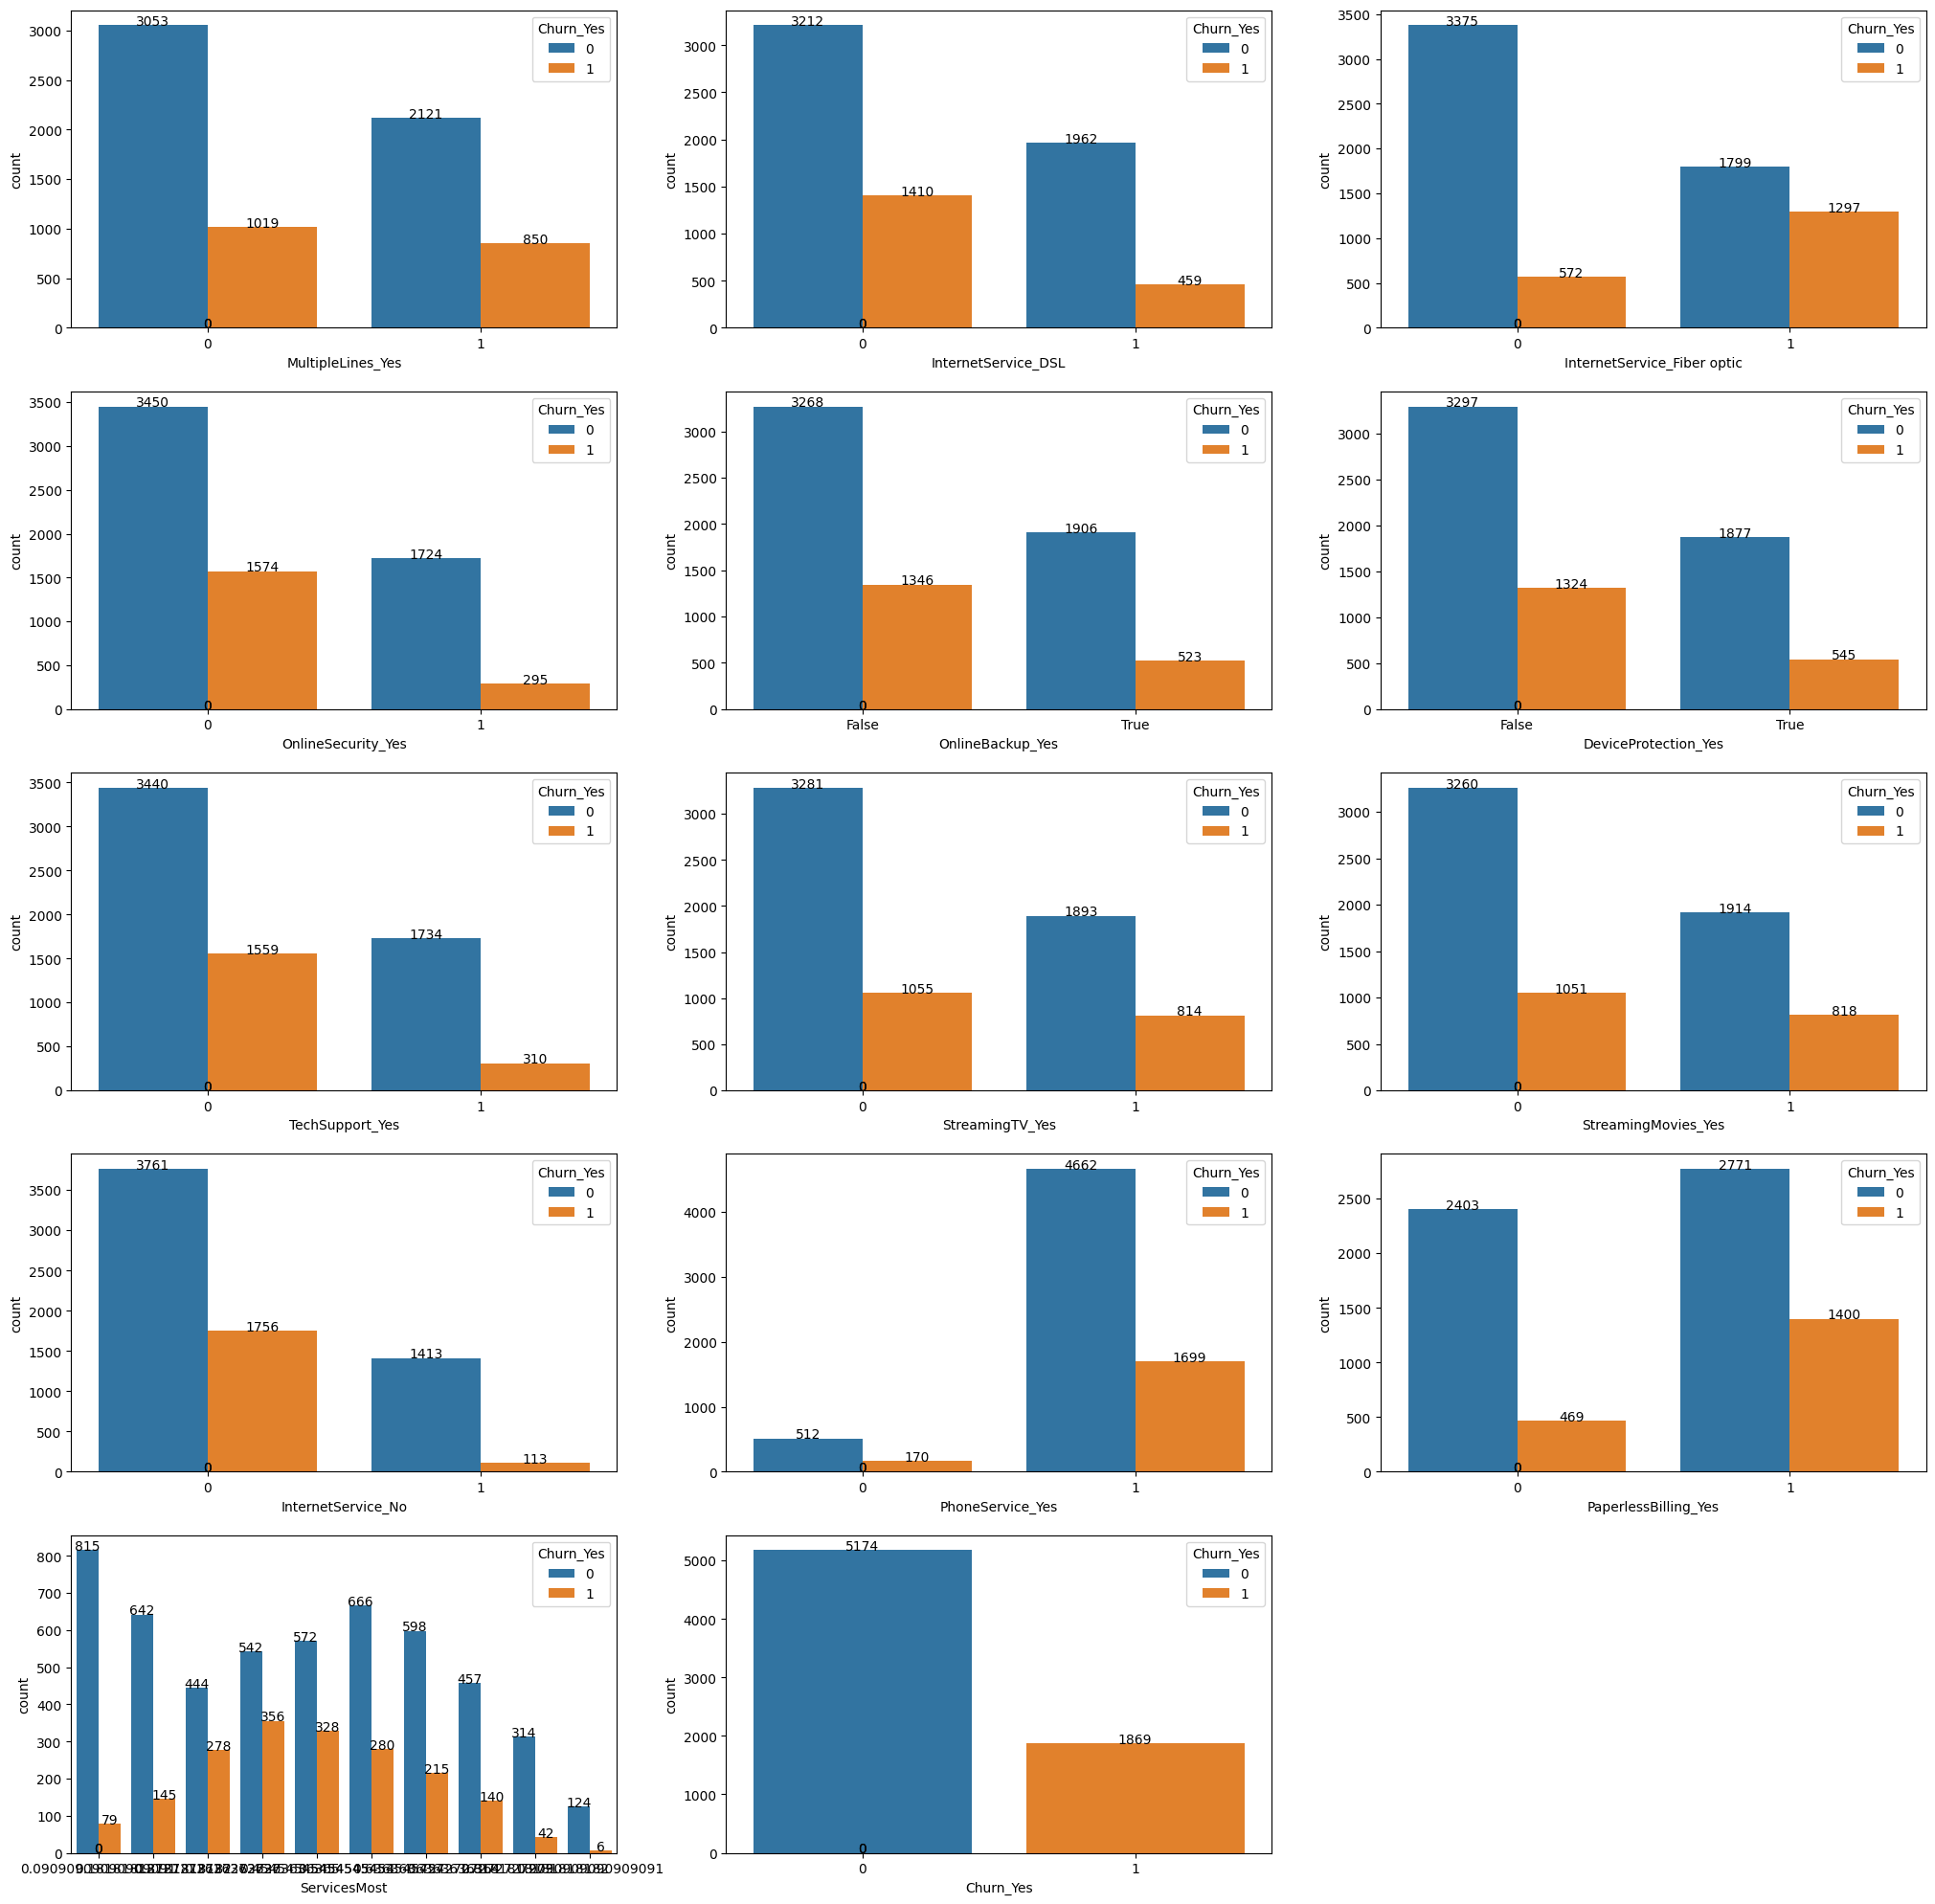

In [98]:
# Create countplot for every services features
plt.figure(figsize=(25,25))
for i, column in enumerate(data_encoded[services]):
    plt.subplot(5, 3, i+1)
    sns.countplot(data=data_encoded[services], x=column, hue="Churn_Yes")
    for p in plt.gca().patches:
        plt.text(p.get_x() + p.get_width() / 2., p.get_height(), '%d' % int(p.get_height()), ha='center')
plt.show()

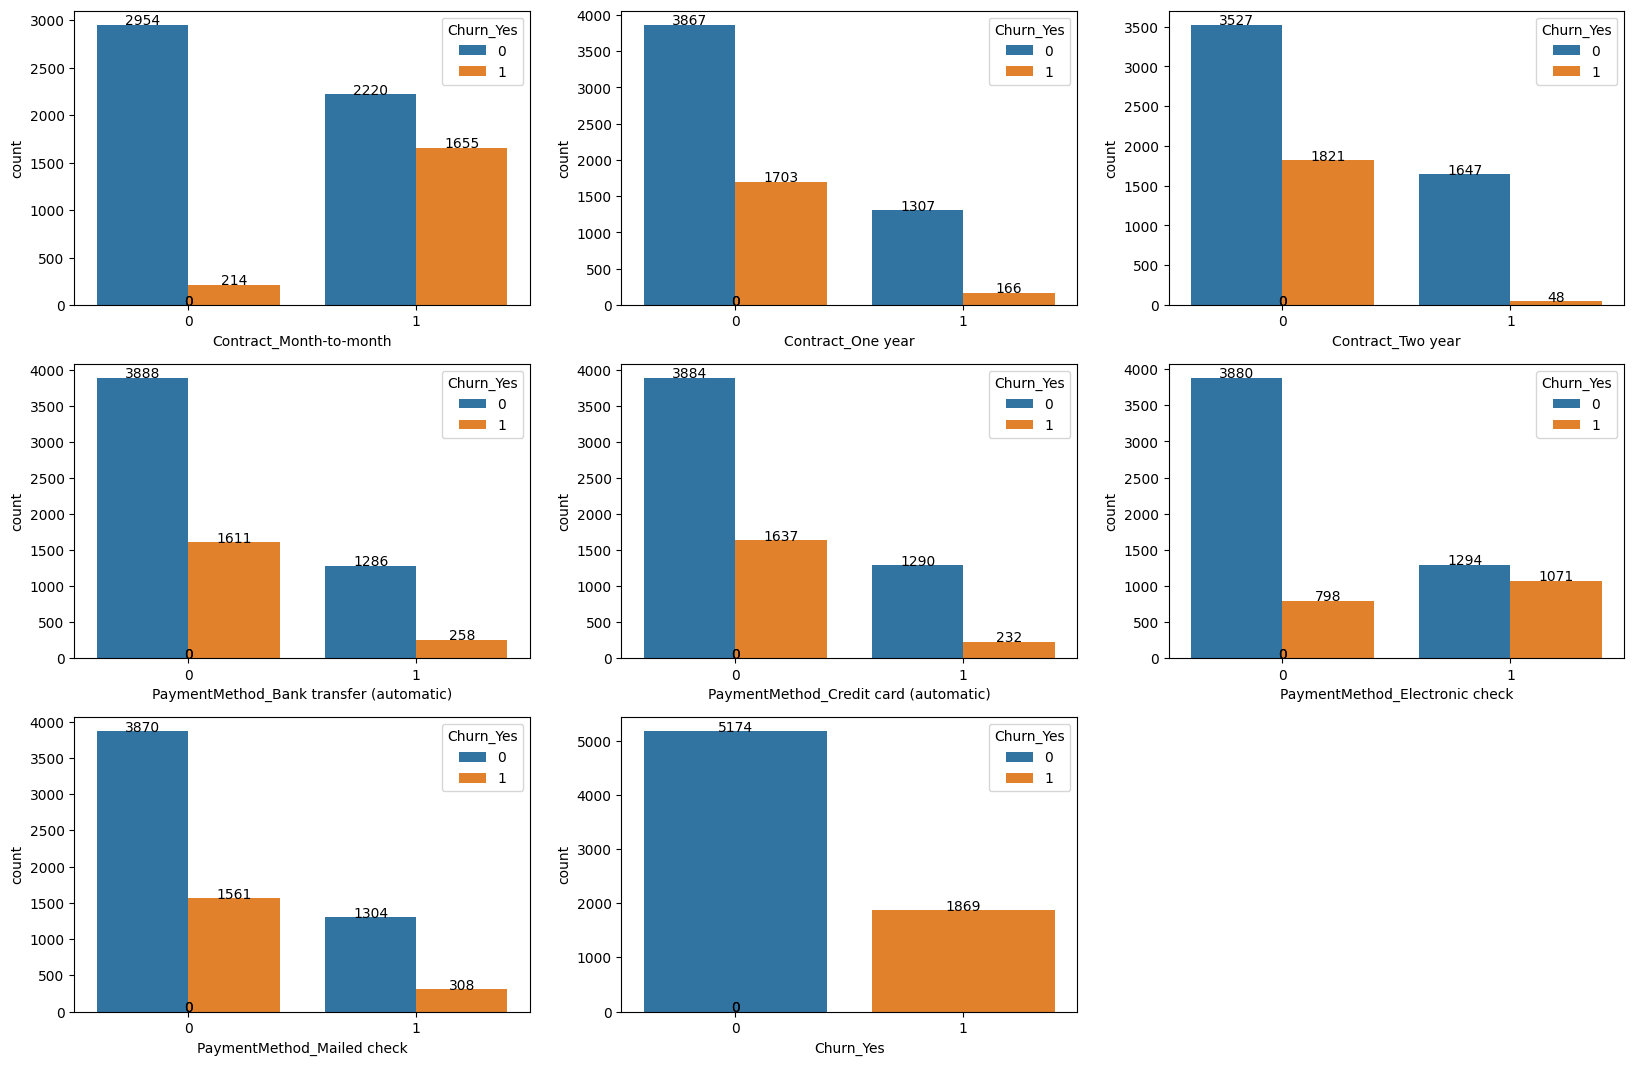

In [99]:
# Create countplot for every other features
plt.figure(figsize=(20,13))
for i, column in enumerate(data_encoded[other]):
    plt.subplot(3, 3, i+1)
    sns.countplot(data=data_encoded[other], x=column, hue="Churn_Yes")
    for p in plt.gca().patches:
        plt.text(p.get_x() + p.get_width() / 2., p.get_height(), '%d' % int(p.get_height()), ha='center')
plt.show()

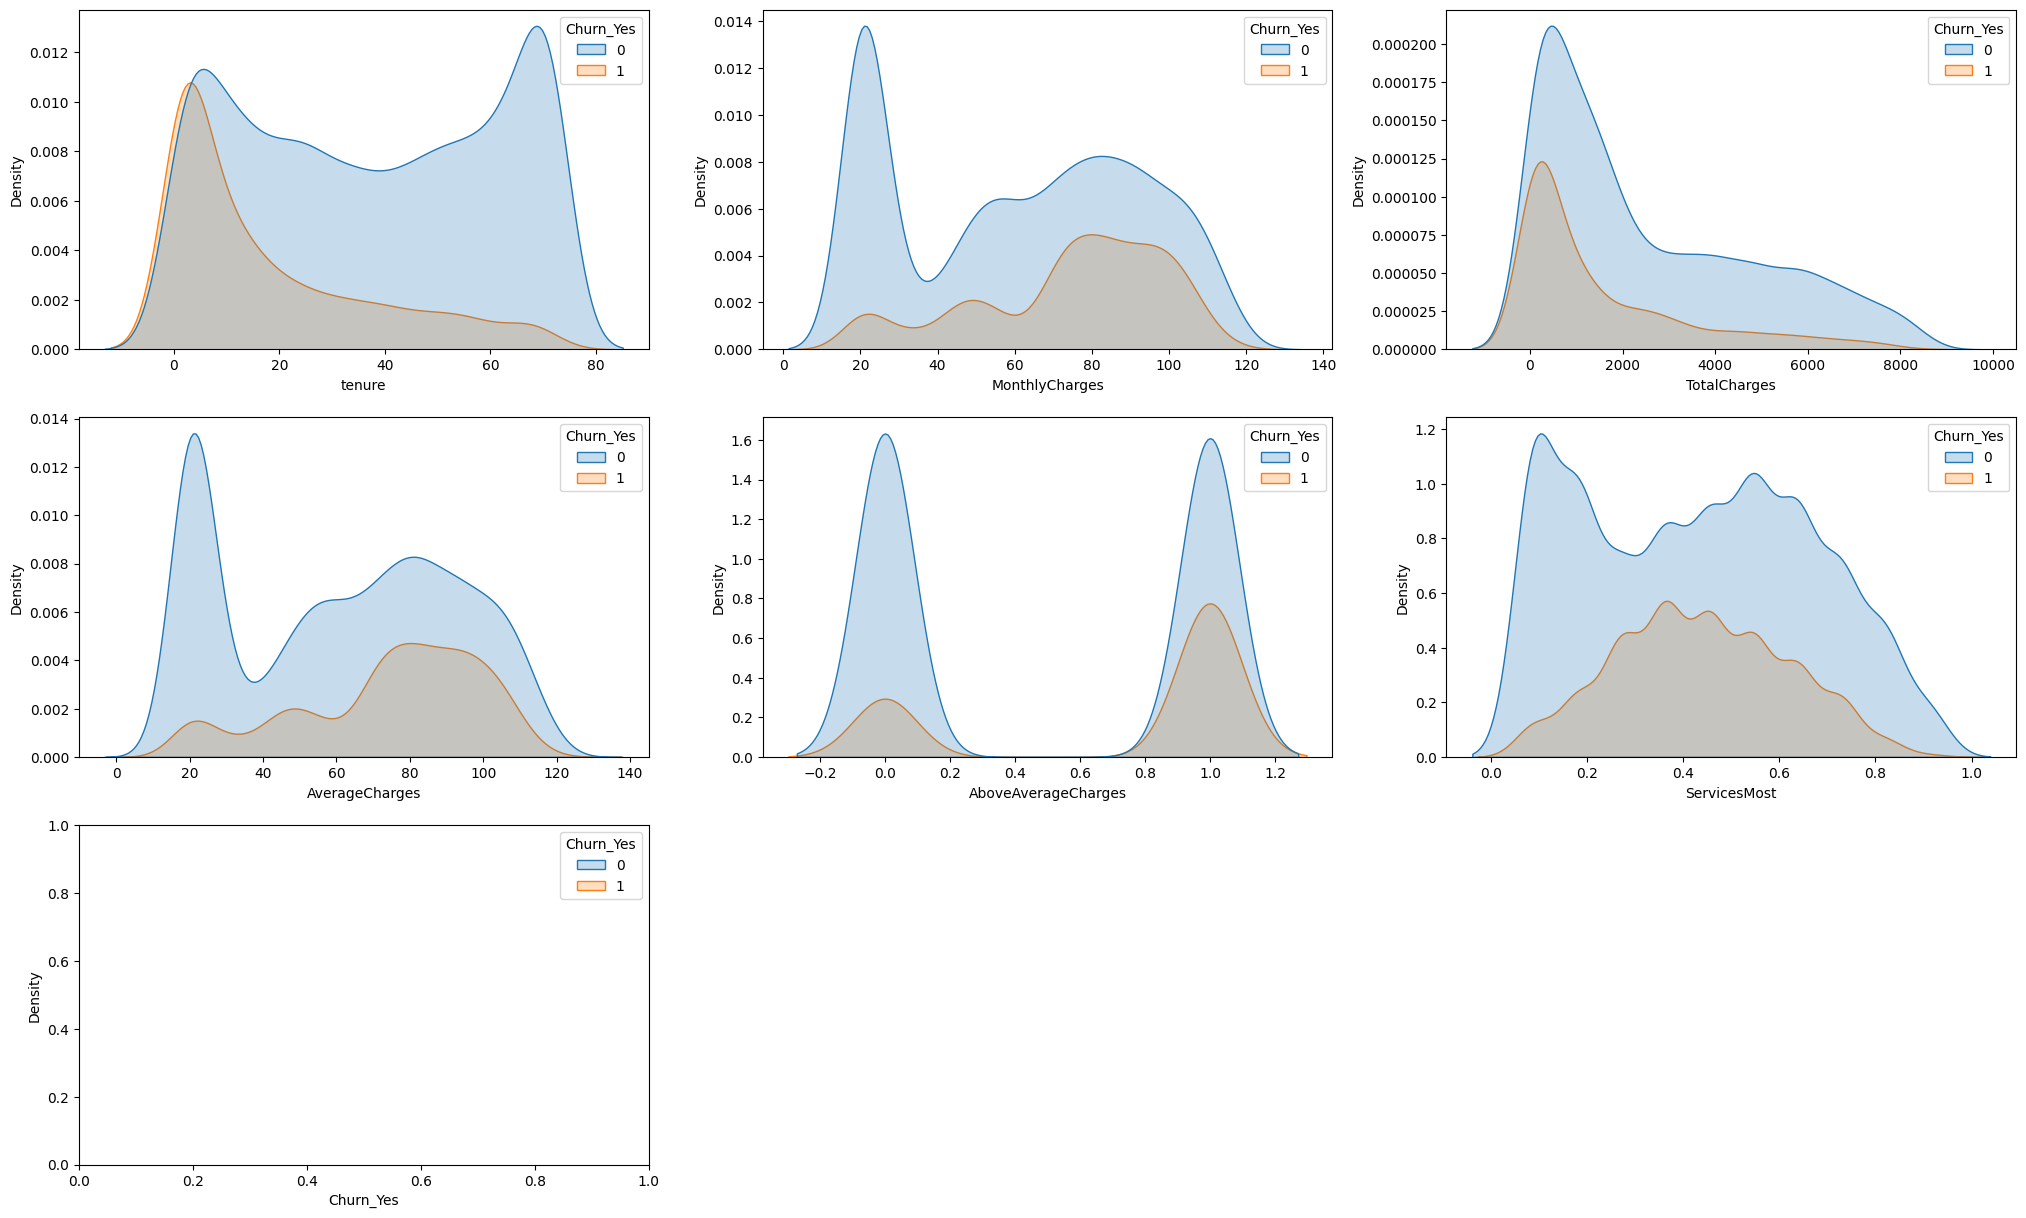

In [100]:
# Examine the distribution of numerical features based on churn
plt.figure(figsize=(25,15))
for i, column in enumerate(data_encoded[numerical]):
    plt.subplot(3, 3, i+1)
    sns.kdeplot(data=data_encoded[numerical], x=column, fill=True, hue="Churn_Yes", warn_singular=False)
plt.show()

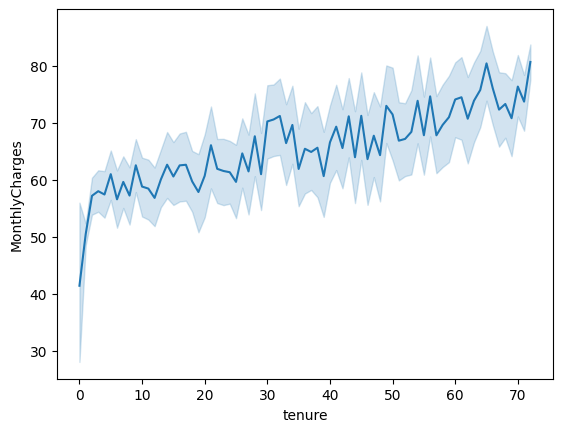

In [101]:
# In conventional scenarios, one might anticipate a negative correlation, where as tenure increases,
# monthly charges decrease or remain stable, as a way of rewarding long-term customers.
sns.lineplot(data=data_encoded, x="tenure", y="MonthlyCharges")
plt.show()

## Conclusions
1) Contract Types:

- The countplot reveals a higher churn rate for month-to-month contracts.

**Recommendation**: Offer incentives for longer contracts to reduce churn.

2) Numerical Features:

- There is a negative correlation with churn for tenure, total charges, and services most.
- There is a positive correlation with churn for monthly charges and above-average charges.
  
**Recommendations**:
- Provide more value-added services and consider reducing monthly charges to enhance overall satisfaction.
- Implement loyalty programs or rewards to incentivize and retain long-term customers.

3) Payment Methods:

- Customers using electronic check have a higher churn rate.

**Recommendation**: Offer a variety of payment options to enhance customer convenience and potentially reduce churn.

4) Tenure and Monthly Charges:

- Customers who churn tend to have lower tenure and higher monthly charges.

**Recommendations**:
- Focus on improving service quality and customer support to retain customers.
- Evaluate pricing strategies to ensure competitiveness and increase customer loyalty.

**Conclusions**:

- Contract incentives for longer terms have the potential to reduce churn.
- Providing additional value, optimizing pricing models, and rewarding loyalty can enhance overall customer satisfaction.
- Offering diverse payment options is crucial for customer convenience and churn reduction.
- Addressing service quality, customer support, and pricing competitiveness are key elements for customer retention.
  
**Next Steps**:

- Implement targeted customer retention programs based on identified factors, such as contract types and payment methods.
- Explore further segmentation using the "cluster" feature to tailor retention strategies.
- Continuously monitor and analyze customer feedback for ongoing service improvements.

**Overall Recommendations**:

- Develop comprehensive strategies focusing on customer satisfaction, loyalty incentives, and service enhancements to effectively reduce churn and foster long-term customer retention.

## Modelling

In [117]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import ADASYN
from sklearn.metrics import classification_report, roc_auc_score
     

# Split the data into features and target
X = data_encoded.drop("Churn_Yes", axis=1)
y = data_encoded["Churn_Yes"]

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Scale the data
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Apply oversampling to only train data
adasyn = ADASYN(sampling_strategy=1, random_state=0)
X_train, y_train = adasyn.fit_resample(X_train, y_train)

In [123]:
# Create a default XGBoost classifier
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

model = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    n_estimators=150,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)

print("Classification Report:")
print(classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc)

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.83      0.84      1041
           1       0.56      0.62      0.59       368

    accuracy                           0.77      1409
   macro avg       0.71      0.72      0.72      1409
weighted avg       0.78      0.77      0.78      1409

ROC-AUC Score: 0.8209941318965878


## Feature Importance

In [119]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

print(importance.head(10))

Contract_Month-to-month        0.380963
InternetService_Fiber optic    0.102742
StreamingMovies_Yes            0.055749
OnlineSecurity_Yes             0.036791
Contract_One year              0.033251
StreamingTV_Yes                0.030465
PaperlessBilling_Yes           0.028286
Dependents_Yes                 0.027242
TechSupport_Yes                0.025796
OnlineBackup_Yes               0.024647
dtype: float32


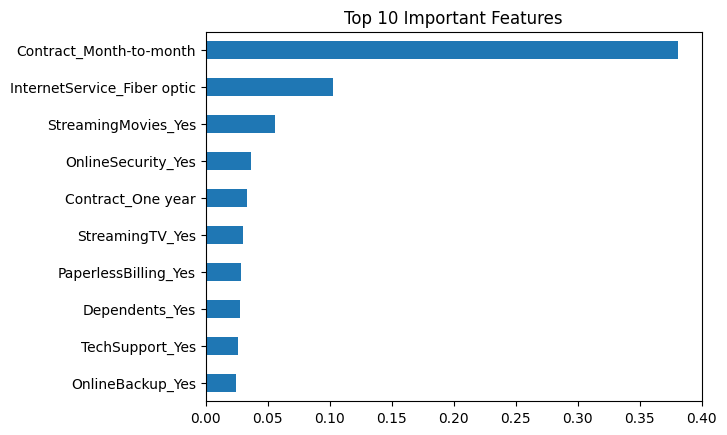

In [120]:
import matplotlib.pyplot as plt

importance.head(10).plot(kind='barh')
plt.title("Top 10 Important Features")
plt.gca().invert_yaxis()
plt.show()

### Key Findings:
- Customers with month-to-month contracts have the highest churn risk
- Fiber optic users are more likely to churn, possibly due to pricing or service quality
- Lack of technical support and online security increases churn probability
- Customers with long-term contracts (1 year) show higher retention
- Users with paperless billing are more likely to switch services
- Customers with dependents tend to stay longer